# Example: Sensitivity Analysis

This notebook provides tutorial and code for running sensitivity analysis to determine what parameters make the largest impact on the model.

In [1]:
from garisom_tools import SperryModel
from garisom_tools.config import MetricConfig
from garisom_tools.sa import SensitivityAnalysisConfig, SensitivityAnalysis

from datetime import datetime
import os
import pandas as pd
import numpy as np
import json

/Users/colinpannikkat/Documents/schoolwork/FEL/garisom/03_test_data/fremont-poplar-data/garisom-tools/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-12 16:44:11,679	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-12 16:44:12,335	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Setup model

In [2]:
# Absolute path directory links needed
model_dir = os.path.abspath("./garisom/02_program_code/")
param_directory = os.path.abspath("./DBG/")

In [3]:
# Set population (corresponds to line in parameters.csv file)
population = 1

In [4]:
# Function to get parameter and configuration files
def get_parameter_and_configuration_files(base_dir: str) -> tuple[str, pd.DataFrame]:
    return os.path.abspath(os.path.join(base_dir, "configuration.csv")), \
        pd.read_csv(os.path.join(base_dir, "parameters.csv"))

model_config, params = get_parameter_and_configuration_files(param_directory)

In [5]:
# Fetch the ground truth csv file for population
def get_ground_truth(population: int):
    ground_dir = "./files/ground"
    match population:
        case 1:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/ccr_hourly_data.csv"))
        case 2:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/jla_hourly_data.csv"))
        case 3:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/nrv_hourly_data.csv"))
        case 4:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/tsz_hourly_data.csv"))
        case _:
            raise Exception("Incorrect POP_NUM!")

    return ground
ground = get_ground_truth(population)

In [6]:
# Necessary start and date datetime instances for evaluation and optimization
start_date = datetime(2023, 7, 20)
end_date = datetime(2023, 8, 24)

In [7]:
# When running, it is necessary to pass in the following run_kwargs and eval_kwargs
run_kwargs = {
    'params': params,
    'config_file': model_config,
    'model_dir': model_dir,
    'population': population,
    'verbose': False
}
eval_kwargs = {
    'ground': ground,
    'start_date': start_date,
    'end_date': end_date
}

In [8]:
model = SperryModel(run_kwargs=run_kwargs, eval_kwargs=eval_kwargs)  # create model

## Setup sensitivity analysis

In [9]:
sa_config_dict = {
    "problem": {
        "num_vars": 2,
        "names": [
            "i_leafWidth",
            "i_leafAreaIndex",
        ],
        "bounds": [
            [0.001, 0.1],
            [0.2192, 7.0008],
        ],
        "dists": [  # specify distribution, see sa/config.py
            "unif",
            "unif",
        ]
    },
    "metric": {
        "params": ["leaftemp", "leaf-air-temp-diff"],
        "metrics": ["nnse", "nnse"],
        "modes": ["max", "max"]
    },
    "workers": 4,
    "samples": 16,  # total samples calculated as N * (D + 2)
    "start_date": start_date,
    "end_date": end_date,
    "pop": population
}

In [10]:
sa_config = SensitivityAnalysisConfig.from_dict(sa_config_dict)

## Run SA

In [11]:
sa = SensitivityAnalysis(
    model=model,
    config=sa_config
)

In [12]:
first, total, first_err, tot_err = sa.run("./sa_out")  # runs sensitivity analysis and outputs files to dir

100%|██████████| 64/64 [01:17<00:00,  1.21s/it]
/Users/colinpannikkat/Documents/schoolwork/FEL/garisom/03_test_data/fremont-poplar-data/garisom-tools/env/lib/python3.12/site-packages/SALib/analyze/sobol.py:141: RuntimeWarning: invalid value encountered in divide
  Y = (Y - Y.mean()) / Y.std()


## Visualize SA

In [13]:
problem = sa_config_dict['problem']

out = np.load("./sa_out/sa_results/model_output.npy")
out = np.nan_to_num(out)  # Replace NaN values with 0

sample = np.load("./sa_out/sa_results/sample.npy", allow_pickle=True)
sample = np.array([[samp[name] for name in problem['names']] for samp in sample])

metrics = MetricConfig.from_dict(sa_config_dict['metric'])
out_names = list({metric.output_name for metric in metrics.metrics})

with open("./sa_out/sa_results/errors.json") as f:
        errors = json.load(f)

N, T, D = out.shape # number of time outputs, number of samples, number of output dimensions
N, I = sample.shape

In [14]:
# Graph arguments
bins = 25
max_ticks = 25

In [39]:
sample.shape

(64, 2)

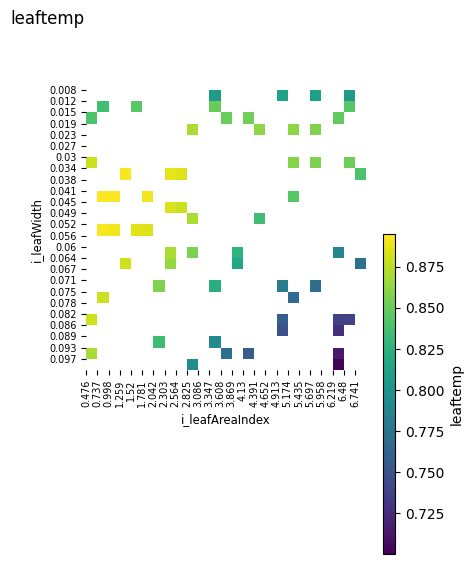

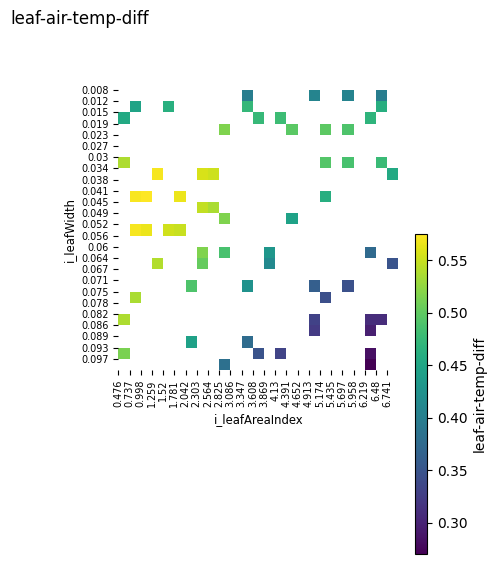

In [52]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
import seaborn as sns


n_inputs = problem['num_vars']
figsize = 4

for d in range(D):

    col = metrics.metrics[d].output_name
    z = errors[metrics.metrics[d].name]

    vmin, vmax = np.inf, -np.inf
    stat_matrices = {}

    # Precompute stats for all unique pairs
    for i in range(n_inputs):
        for j in range(i + 1, n_inputs):
            x = sample[:, i]
            y = sample[:, j]
            stat, _, _, _ = binned_statistic_2d(x, y, z, statistic='mean', bins=bins)
            stat_matrices[(i, j)] = stat
            vmin = np.nanmin([vmin, np.nanmin(stat)])
            vmax = np.nanmax([vmax, np.nanmax(stat)])

    fig, axes = plt.subplots(n_inputs, n_inputs, figsize=(figsize * n_inputs, figsize * n_inputs), squeeze=False)

    for i in range(n_inputs):
        for j in range(n_inputs):
            ax = axes[i, j]

            if j <= i:
                fig.delaxes(ax)
                continue

            x = sample[:, i]
            y = sample[:, j]
            stat = stat_matrices[(i, j)]
            x_edges = np.linspace(x.min(), x.max(), bins + 1)
            y_edges = np.linspace(y.min(), y.max(), bins + 1)

            sns.heatmap(
                stat,
                ax=ax,
                xticklabels=False,
                yticklabels=False,
                cmap="viridis",
                vmin=vmin,
                vmax=vmax,
                cbar=False,
                square=True
            )

            step_x = max(1, len(x_edges) // max_ticks)
            x_tick_indices = np.arange(0, len(x_edges) - 1, step_x)
            x_tick_labels = np.round((x_edges[x_tick_indices] + x_edges[x_tick_indices + 1]) / 2, 3)

            step_y = max(1, len(y_edges) // max_ticks)
            y_tick_indices = np.arange(0, len(y_edges) - 1, step_y)
            y_tick_labels = np.round((y_edges[y_tick_indices] + y_edges[y_tick_indices + 1]) / 2, 3)

            if j == i + 1:
                ax.set_yticks(x_tick_indices)
                ax.set_yticklabels(x_tick_labels, fontsize='x-small', rotation=0)
                ax.set_ylabel(problem["names"][i], fontsize="small")

            if i == j - 1:
                ax.set_xticks(y_tick_indices)
                ax.set_xticklabels(y_tick_labels, fontsize='x-small', rotation=90)
                ax.set_xlabel(problem["names"][j], fontsize="small")

    cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])
    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label=f"{col}")

    plt.suptitle(f"{col}", fontsize="large")
    plt.show()


In [16]:
indices = total
error_indices = tot_err
t_range = range(0, T)

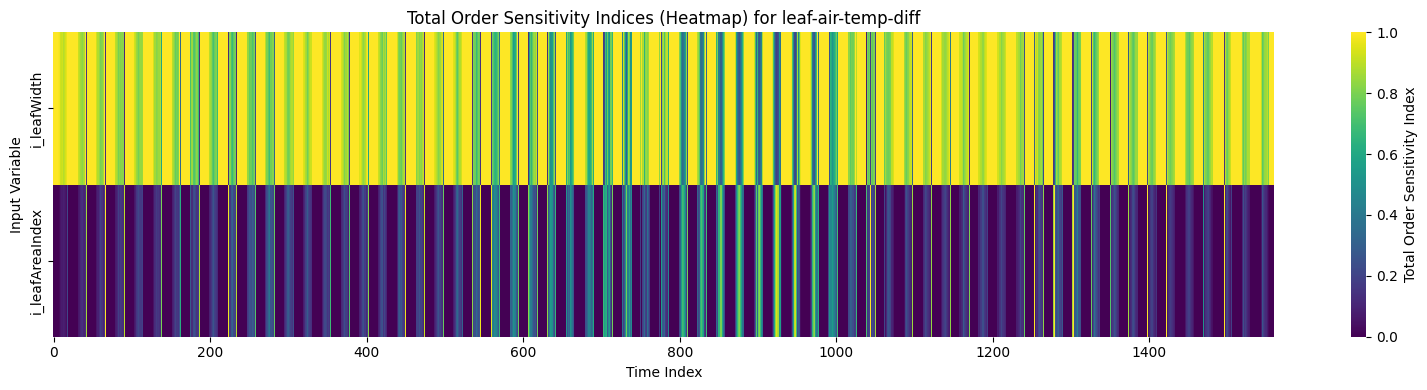

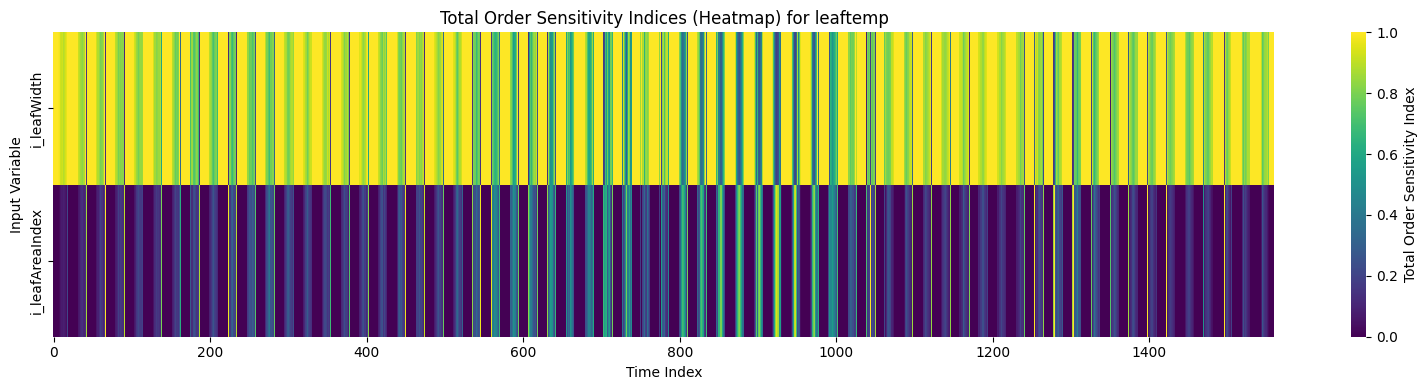

In [17]:
# Output SA Indices
for d in range(D):
    plt.figure(figsize=(16, 4))

    sns.heatmap(
        indices[d, :, t_range.start:t_range.stop],
        cmap='viridis',
        cbar_kws={'label': 'Total Order Sensitivity Index'},
        xticklabels=200,
        yticklabels=problem['names']
    )
    plt.xlabel('Time Index')
    plt.ylabel('Input Variable')
    plt.title(f'Total Order Sensitivity Indices (Heatmap) for {out_names[d]}')
    plt.tight_layout()
    plt.show()

<Figure size 1600x400 with 0 Axes>

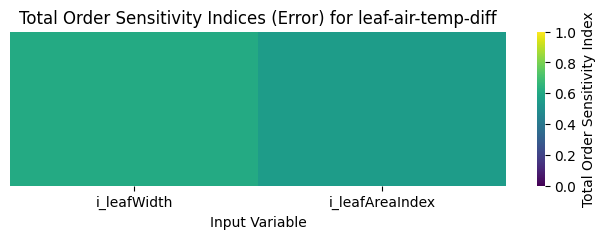

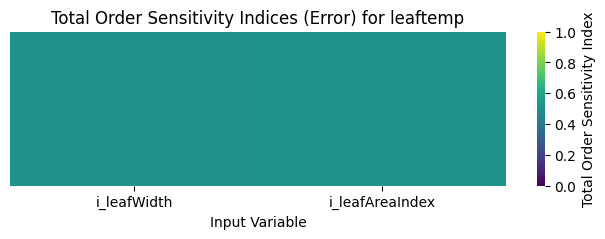

In [18]:
# Error SA Indices
plt.figure(figsize=(16, 4))

for d in range(D):
    plt.figure(figsize=(8, 2))
    sns.heatmap(
        error_indices[d, :].reshape(1, I),
        cmap='viridis',
        cbar_kws={'label': 'Total Order Sensitivity Index'},
        vmin=0, vmax=1,
        xticklabels=problem['names'],
        yticklabels=False
    )
    plt.xlabel('Input Variable')
    plt.ylabel('')
    plt.title(f'Total Order Sensitivity Indices (Error) for {out_names[d]}')
    plt.show()